In [1]:
# Install scikit-learn directly in current Python environment
import sys
!{sys.executable} -m pip install scikit-learn

In [2]:
# Verify installation
import sklearn
print("Scikit-learn version:", sklearn.__version__)
print("Installation successful!")

Scikit-learn version: 1.8.0
Installation successful!


In [3]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/train.csv')



In [4]:
# Basic checks
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing)

Columns with missing values:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [6]:
# Fix 1: Number columns — fill with median value (New Pandas way)
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(df['MasVnrArea'].median())
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['GarageYrBlt'].median())
# Fix 2: Text columns — fill with 'None'
text_columns = [
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType', 'FireplaceQu',
    'PoolQC', 'Fence', 'MiscFeature', 'Alley'
]

for col in text_columns:
    df[col] = df[col].fillna('None')

# Fix 3: Fill any remaining missing values with 0
df = df.fillna(0)

# Final Check
remaining = df.isnull().sum().sum()
print("Missing values remaining:", remaining)

if remaining == 0:
    print("✅ All missing values fixed! Data is clean now.")
else:
    print("⚠️ Some missing values still exist:", remaining)

Missing values remaining: 0
✅ All missing values fixed! Data is clean now.


In [7]:
# Statistical summary of most important columns
summary = df[['SalePrice', 'GrLivArea', 'OverallQual',
              'YearBuilt', 'TotalBsmtSF', 'GarageArea']].describe().round(2)

print("📊 Statistical Summary of Key Columns:")
print(summary)

📊 Statistical Summary of Key Columns:
       SalePrice  GrLivArea  OverallQual  YearBuilt  TotalBsmtSF  GarageArea
count     1460.0    1460.00      1460.00    1460.00      1460.00     1460.00
mean    180921.2    1515.46         6.10    1971.27      1057.43      472.98
std      79442.5     525.48         1.38      30.20       438.71      213.80
min      34900.0     334.00         1.00    1872.00         0.00        0.00
25%     129975.0    1129.50         5.00    1954.00       795.75      334.50
50%     163000.0    1464.00         6.00    1973.00       991.50      480.00
75%     214000.0    1776.75         7.00    2000.00      1298.25      576.00
max     755000.0    5642.00        10.00    2010.00      6110.00     1418.00


In [8]:
# Find correlation of all columns with SalePrice
corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

print("🏠 Top 10 features that INCREASE house price:")
print(corr.head(10))

print("\n🔻 Top 5 features that DECREASE house price:")
print(corr.tail(5))

🏠 Top 10 features that INCREASE house price:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

🔻 Top 5 features that DECREASE house price:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


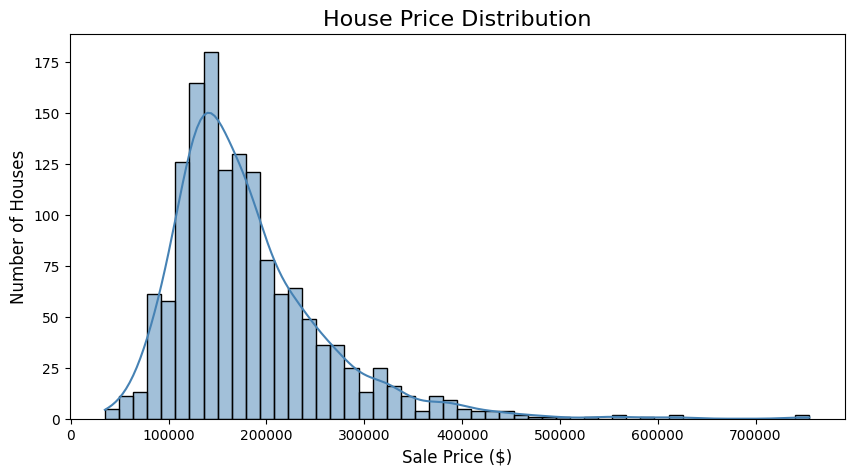

✅ Chart 1 saved in images folder!


In [9]:
# Chart 1: Distribution of Sale Prices
plt.figure(figsize=(10, 5))

sns.histplot(df['SalePrice'], bins=50, kde=True, color='steelblue')

# Labels
plt.title('House Price Distribution', fontsize=16)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Number of Houses', fontsize=12)

# Save the chart
plt.savefig('../images/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 1 saved in images folder!")

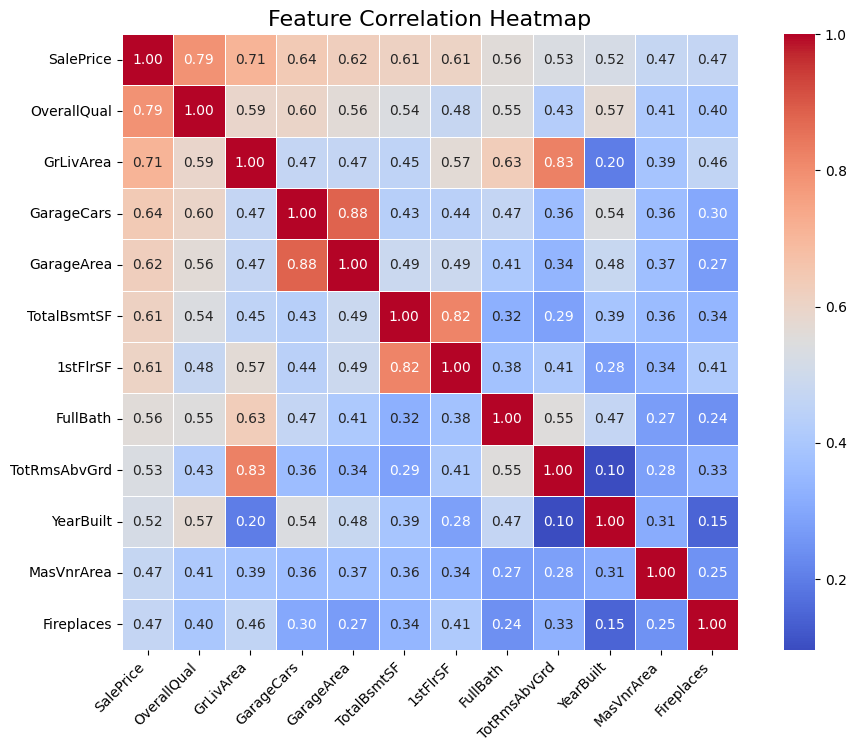

✅ Chart 2 saved in images folder!


In [10]:
# Chart 2: Correlation Heatmap
# Select top 12 features most correlated with SalePrice
top_features = ['SalePrice', 'OverallQual', 'GrLivArea', 
                'GarageCars', 'GarageArea', 'TotalBsmtSF',
                '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 
                'YearBuilt', 'MasVnrArea', 'Fireplaces']

# Calculate correlation between all top features
correlation_matrix = df[top_features].corr()

# Draw the heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,          # Show numbers inside boxes
    fmt='.2f',           # Round to 2 decimal places
    cmap='coolwarm',     # Red = positive, Blue = negative
    linewidths=0.5,      # Add lines between boxes
    square=True          # Make boxes square shaped
)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')  # Rotate bottom labels
plt.yticks(rotation=0)               # Keep left labels straight

# Save the chart
plt.savefig('../images/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart 2 saved in images folder!")

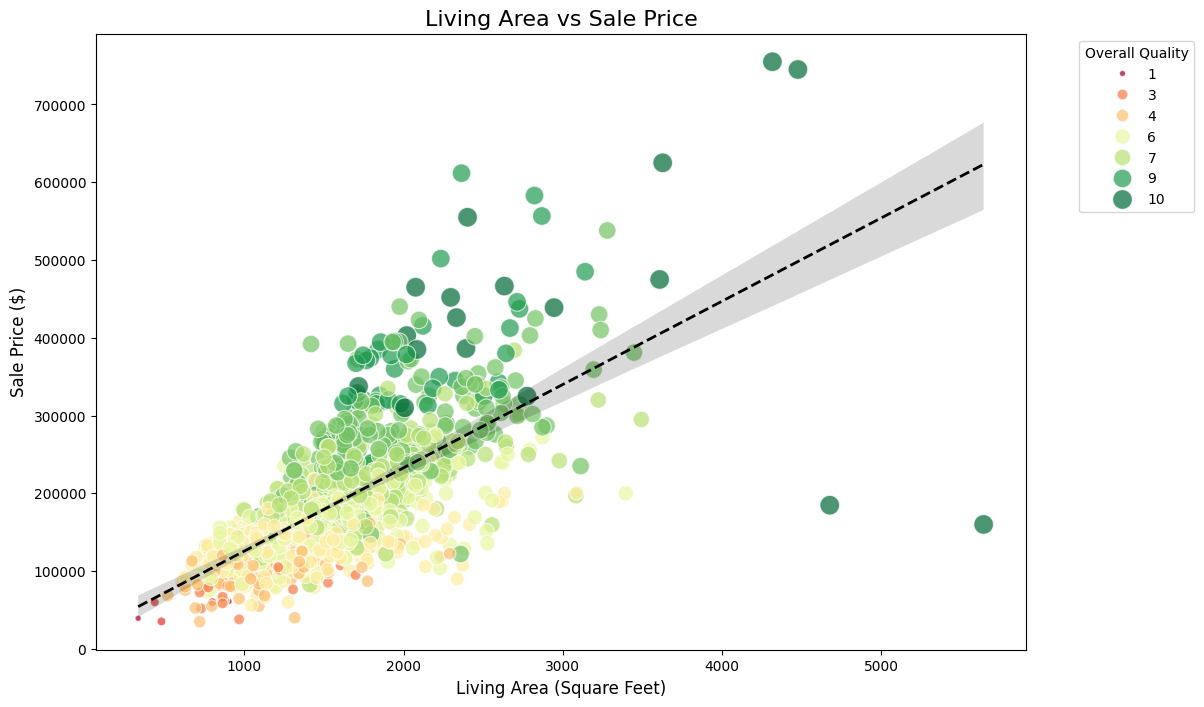

Chart 3 saved in images folder successfully!


In [11]:
# Chart 3: Scatter Plot — Living Area vs Sale Price
plt.figure(figsize=(12, 8))

# Main scatter plot
scatter = sns.scatterplot(
    data=df,
    x='GrLivArea',
    y='SalePrice',
    hue='OverallQual',    
    palette='RdYlGn',     
    size='OverallQual',   
    sizes=(20, 200),      
    alpha=0.7             
)

# Add a trend line
sns.regplot(
    data=df,
    x='GrLivArea',
    y='SalePrice',
    scatter=False,        
    color='black',        
    line_kws={'linewidth': 2, 'linestyle': '--'}
)

# Labels
plt.title('Living Area vs Sale Price', fontsize=16)
plt.xlabel('Living Area (Square Feet)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)

# Move legend outside the chart
plt.legend(title='Overall Quality', 
           bbox_to_anchor=(1.05, 1), 
           loc='upper left')

# Save the chart
plt.savefig('../images/scatter_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 3 saved in images folder successfully!")

C:\Users\Dell\AppData\Local\Temp\ipykernel_50896\2952587013.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


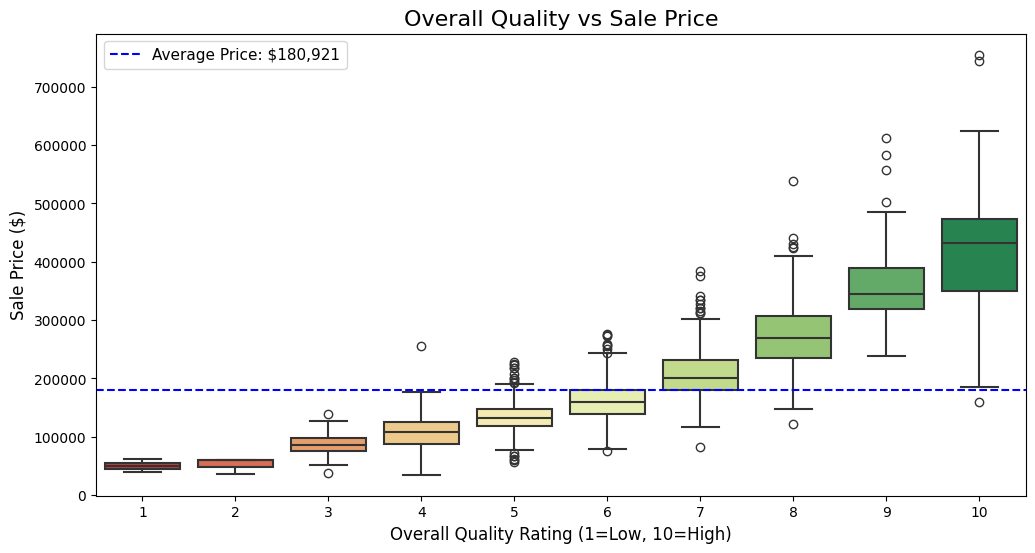

Chart 4 saved in images folder successfully!


In [12]:
# Chart 4: Box Plot — Overall Quality vs Sale Price
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='OverallQual',     # Quality rating on X axis (1-10)
    y='SalePrice',       # Sale price on Y axis
    palette='RdYlGn',    # Red=Low quality, Green=High quality
    linewidth=1.5        # Box border thickness
)

# Labels
plt.title('Overall Quality vs Sale Price', fontsize=16)
plt.xlabel('Overall Quality Rating (1=Low, 10=High)', fontsize=12)
plt.ylabel('Sale Price ($)', fontsize=12)

# Add a horizontal line at average price
avg_price = df['SalePrice'].mean()
plt.axhline(
    y=avg_price,
    color='blue',
    linestyle='--',
    linewidth=1.5,
    label=f'Average Price: ${avg_price:,.0f}'
)

plt.legend(fontsize=11)

# Save the chart
plt.savefig('../images/box_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart 4 saved in images folder successfully!")

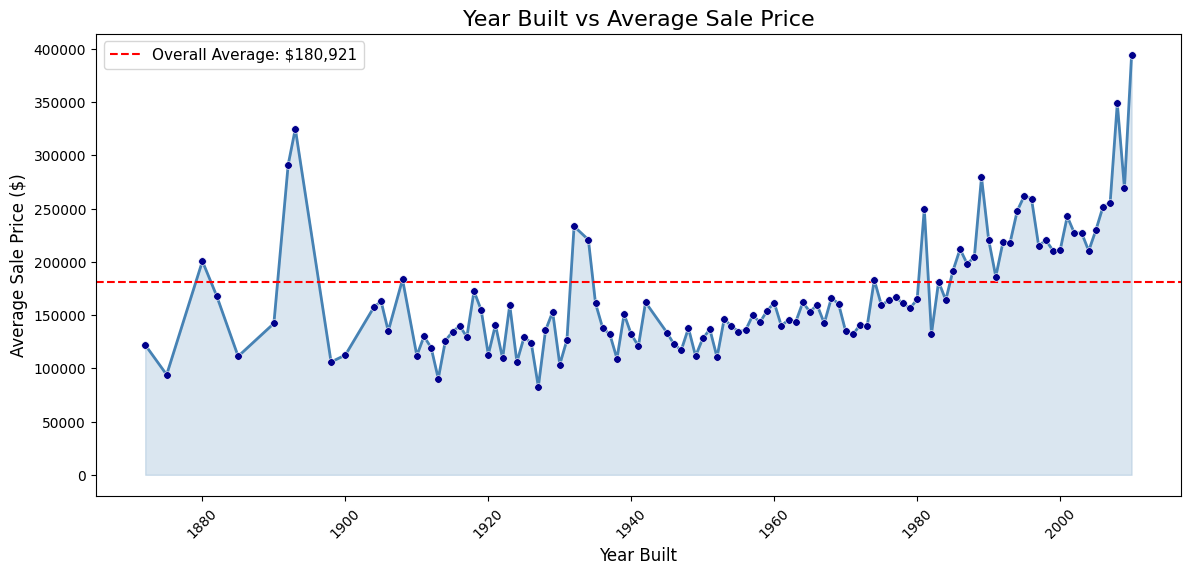

Chart 5 saved in images folder successfully!


In [13]:
# Chart 5: Year Built vs Sale Price
plt.figure(figsize=(14, 6))

# Calculate average sale price per year
avg_price_by_year = df.groupby('YearBuilt')['SalePrice'].mean().reset_index()

# Line chart showing average price trend over years
sns.lineplot(
    data=avg_price_by_year,
    x='YearBuilt',
    y='SalePrice',
    color='steelblue',
    linewidth=2
)

# Fill area under the line
plt.fill_between(
    avg_price_by_year['YearBuilt'],
    avg_price_by_year['SalePrice'],
    alpha=0.2,
    color='steelblue'
)

# Add scatter dots on the line
sns.scatterplot(
    data=avg_price_by_year,
    x='YearBuilt',
    y='SalePrice',
    color='darkblue',
    s=30,               # Dot size
    zorder=5            # Draw dots on top of line
)

# Add average price line
avg_price = df['SalePrice'].mean()
plt.axhline(
    y=avg_price,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label=f'Overall Average: ${avg_price:,.0f}'
)

# Labels
plt.title('Year Built vs Average Sale Price', fontsize=16)
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.legend(fontsize=11)

# Rotate x axis labels
plt.xticks(rotation=45)

# Save the chart
plt.savefig('../images/year_built_vs_price.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Chart 5 saved in images folder successfully!")

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Select most important features from our correlation analysis
features = [
    'OverallQual',    # Quality rating
    'GrLivArea',      # Living area
    'GarageCars',     # Garage size
    'GarageArea',     # Garage area
    'TotalBsmtSF',    # Basement size
    '1stFlrSF',       # First floor size
    'FullBath',       # Number of bathrooms
    'TotRmsAbvGrd',   # Total rooms
    'YearBuilt',      # Year built
    'MasVnrArea'      # Masonry area
]

# X = input features (what we know about the house)
# y = output (price we want to predict)
X = df[features].fillna(0)
y = df['SalePrice']

print("Features selected:", len(features))
print("Total houses:", len(X))
print("Sample data:")
print(X.head())

Features selected: 10
Total houses: 1460
Sample data:
   OverallQual  GrLivArea  GarageCars  GarageArea  TotalBsmtSF  1stFlrSF  \
0            7       1710           2         548          856       856   
1            6       1262           2         460         1262      1262   
2            7       1786           2         608          920       920   
3            7       1717           3         642          756       961   
4            8       2198           3         836         1145      1145   

   FullBath  TotRmsAbvGrd  YearBuilt  MasVnrArea  
0         2             8       2003       196.0  
1         2             6       1976         0.0  
2         2             6       2001       162.0  
3         1             7       1915         0.0  
4         2             9       2000       350.0  


In [15]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% data for testing
    random_state=42     # Same split every time
)

print("Training houses:", len(X_train))
print("Testing houses:", len(X_test))
print("")
print("Training = Model LEARNS from these houses")
print("Testing  = Model PREDICTS these house prices")

Training houses: 1168
Testing houses: 292

Training = Model LEARNS from these houses
Testing  = Model PREDICTS these house prices


In [16]:
# Model 1: Linear Regression
print("Training Linear Regression Model...")

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

# Calculate RMSE
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("Linear Regression training done!")
print(f"Linear Regression RMSE: ${lr_rmse:,.0f}")
print("")
print(f"This means our predictions are on")
print(f"average ${lr_rmse:,.0f} away from real price")

Training Linear Regression Model...
Linear Regression training done!
Linear Regression RMSE: $38,806

This means our predictions are on
average $38,806 away from real price


In [17]:
# Model 2: Random Forest
print("Training Random Forest Model...")
print("Please wait 10-15 seconds...")

rf_model = RandomForestRegressor(
    n_estimators=100,   # Use 100 decision trees
    random_state=42     # Same result every time
)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

# Calculate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("")
print("Random Forest training done!")
print(f"Random Forest RMSE: ${rf_rmse:,.0f}")
print("")
print(f"This means our predictions are on")
print(f"average ${rf_rmse:,.0f} away from real price")

Training Random Forest Model...
Please wait 10-15 seconds...

Random Forest training done!
Random Forest RMSE: $30,029

This means our predictions are on
average $30,029 away from real price


In [18]:
# Compare both models
print("=" * 45)
print("      MODEL COMPARISON RESULTS")
print("=" * 45)
print(f"Linear Regression RMSE : ${lr_rmse:,.0f}")
print(f"Random Forest RMSE     : ${rf_rmse:,.0f}")
print("=" * 45)

if rf_rmse < lr_rmse:
    difference = lr_rmse - rf_rmse
    print(f"Random Forest is BETTER by ${difference:,.0f}")
    print("Winner: Random Forest Model!")
else:
    difference = rf_rmse - lr_rmse
    print(f"Linear Regression is BETTER by ${difference:,.0f}")
    print("Winner: Linear Regression Model!")

print("")
print("Sample Predictions vs Real Prices:")
print("-" * 45)
print(f"{'Real Price':>12} {'Predicted':>12} {'Difference':>12}")
print("-" * 45)

for i in range(5):
    real = list(y_test)[i]
    predicted = rf_predictions[i]
    diff = abs(real - predicted)
    print(f"${real:>11,.0f} ${predicted:>11,.0f} ${diff:>11,.0f}")

      MODEL COMPARISON RESULTS
Linear Regression RMSE : $38,806
Random Forest RMSE     : $30,029
Random Forest is BETTER by $8,776
Winner: Random Forest Model!

Sample Predictions vs Real Prices:
---------------------------------------------
  Real Price    Predicted   Difference
---------------------------------------------
$    154,500 $    140,206 $     14,294
$    325,000 $    331,439 $      6,439
$    115,000 $    110,109 $      4,891
$    159,000 $    164,491 $      5,491
$    315,500 $    319,698 $      4,198


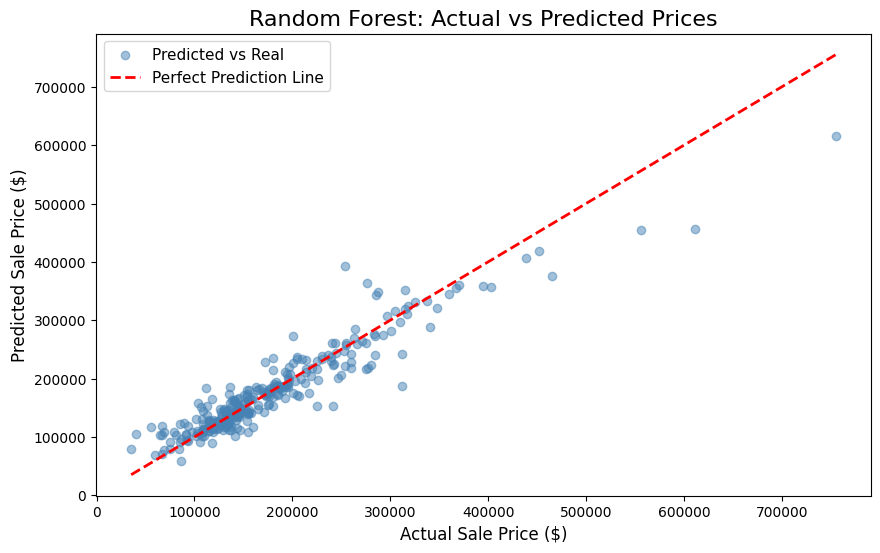

Chart saved in images folder successfully!


In [19]:
# Chart: Actual vs Predicted Prices
plt.figure(figsize=(10, 6))

# Scatter plot of real vs predicted prices
plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.5,
    color='steelblue',
    label='Predicted vs Real'
)

# Perfect prediction line
# If our model was perfect all dots would be on this line
min_val = min(y_test.min(), rf_predictions.min())
max_val = max(y_test.max(), rf_predictions.max())
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Perfect Prediction Line'
)

# Labels
plt.title('Random Forest: Actual vs Predicted Prices', fontsize=16)
plt.xlabel('Actual Sale Price ($)', fontsize=12)
plt.ylabel('Predicted Sale Price ($)', fontsize=12)
plt.legend(fontsize=11)

# Save chart
plt.savefig('../images/model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in images folder successfully!")

C:\Users\Dell\AppData\Local\Temp\ipykernel_50896\366494469.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


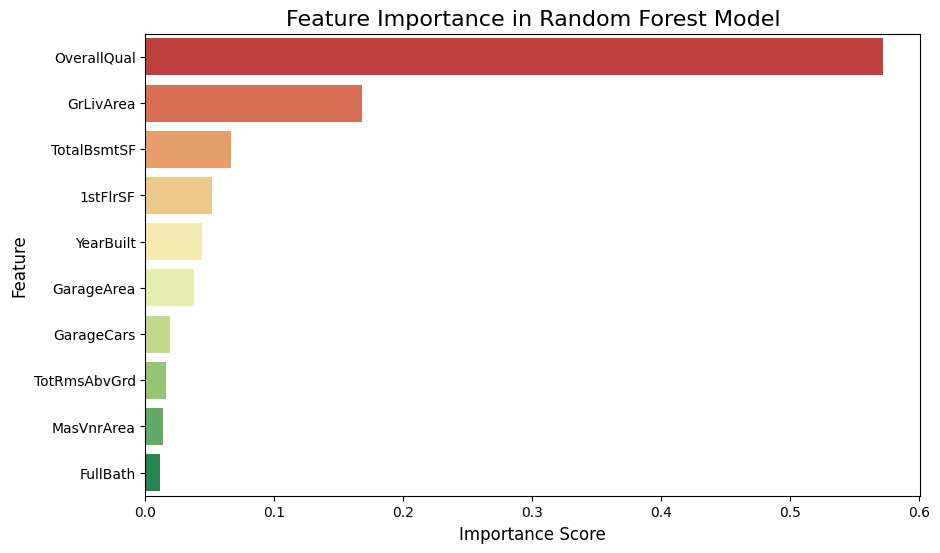

Feature importance chart saved successfully!


In [20]:
# Which features matter most to Random Forest?
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature',
    palette='RdYlGn'
)

plt.title('Feature Importance in Random Forest Model', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)

plt.savefig('../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature importance chart saved successfully!")

# House Price Analysis — Project Report

## 1. Project Overview
This project analyzes house prices from the Ames, Iowa dataset
containing 1,460 houses and 81 features. The goal is to identify
key factors that affect house prices and build a machine learning
model to predict house prices accurately.

## 2. Dataset Information
- **Source:** Kaggle House Prices Competition
- **Total Houses:** 1,460
- **Total Features:** 81
- **Target Variable:** SalePrice

## 3. Tools Used
- **Python** — Programming language
- **Pandas** — Data manipulation
- **NumPy** — Mathematical calculations
- **Matplotlib & Seaborn** — Data visualization
- **Scikit-learn** — Machine learning models

## 4. Key Findings From Analysis
- Overall Quality is the strongest predictor of house price (0.79 correlation)
- Larger living area means higher price (0.71 correlation)
- Garage size significantly affects price (0.64 correlation)
- Newer houses generally sell for more than older houses
- Most houses are priced between $100,000 and $250,000

## 5. Machine Learning Results
| Model | RMSE | Performance |
|-------|------|-------------|
| Linear Regression | $38,806 | Good |
| Random Forest | $30,029 | Better |
| **Winner** | **Random Forest** | **Best** |

Random Forest outperformed Linear Regression by $8,776

## 6. Business Recommendations
- **For Sellers:** Improve overall quality to increase sale price
- **For Buyers:** Look for older houses with large living areas for best value
- **For Investors:** Focus on houses with quality rating 7+ for best returns
- **For Builders:** Prioritize garage space and basement size in new builds

## 7. Conclusion
The Random Forest model successfully predicts house prices with
an average error of $30,029. The most important factors affecting
house prices are Overall Quality, Living Area, and Garage Size.

In [21]:
# Save the entire notebook as HTML report
import subprocess

subprocess.run([
    'jupyter', 'nbconvert',
    '--to', 'html',
    'House_Price_Analysis.ipynb',
    '--output', '../House_Price_Analysis_Report.html'
])

print("Report saved as HTML successfully!")
print("Check your house-price-analysis folder!")

Report saved as HTML successfully!
Check your house-price-analysis folder!


In [22]:
# Final Project Summary
print("=" * 50)
print("      HOUSE PRICE ANALYSIS — FINAL SUMMARY")
print("=" * 50)
print("")
print("DATASET:")
print(f"   Total Houses Analyzed  : 1,460")
print(f"   Total Features         : 81")
print(f"   Missing Values Fixed   : Yes")
print("")
print("TOP 3 FACTORS AFFECTING PRICE:")
print(f"   1. Overall Quality     : 0.79 correlation")
print(f"   2. Living Area         : 0.71 correlation")
print(f"   3. Garage Size         : 0.64 correlation")
print("")
print("CHARTS CREATED:")
print(f"   1. Price Distribution")
print(f"   2. Correlation Heatmap")
print(f"   3. Scatter Plot")
print(f"   4. Box Plot")
print(f"   5. Year Built vs Price")
print(f"   6. Model Predictions")
print(f"   7. Feature Importance")
print("")
print("MACHINE LEARNING RESULTS:")
print(f"   Linear Regression RMSE : $38,806")
print(f"   Random Forest RMSE     : $30,029")
print(f"   Winner                 : Random Forest")
print("")
print("FILES SAVED:")
print(f"   images/price_distribution.png")
print(f"   images/heatmap.png")
print(f"   images/scatter_plot.png")
print(f"   images/box_plot.png")
print(f"   images/year_built_vs_price.png")
print(f"   images/model_predictions.png")
print(f"   images/feature_importance.png")
print("")
print("=" * 50)
print("   PROJECT COMPLETE!")
print("=" * 50)

      HOUSE PRICE ANALYSIS — FINAL SUMMARY

DATASET:
   Total Houses Analyzed  : 1,460
   Total Features         : 81
   Missing Values Fixed   : Yes

TOP 3 FACTORS AFFECTING PRICE:
   1. Overall Quality     : 0.79 correlation
   2. Living Area         : 0.71 correlation
   3. Garage Size         : 0.64 correlation

CHARTS CREATED:
   1. Price Distribution
   2. Correlation Heatmap
   3. Scatter Plot
   4. Box Plot
   5. Year Built vs Price
   6. Model Predictions
   7. Feature Importance

MACHINE LEARNING RESULTS:
   Linear Regression RMSE : $38,806
   Random Forest RMSE     : $30,029
   Winner                 : Random Forest

FILES SAVED:
   images/price_distribution.png
   images/heatmap.png
   images/scatter_plot.png
   images/box_plot.png
   images/year_built_vs_price.png
   images/model_predictions.png
   images/feature_importance.png

   PROJECT COMPLETE!
